In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=01accb5fddd6906a7948ef75d45df616c4fdefe2f20ed2d33bb04497d6ef0804
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as ps

In [ ]:
data = pd.read_csv("/content/airlines_flights_data.csv")
data

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
data.tail()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
data.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [ ]:
# data.isnull()
data.isnull().sum()

,0
index,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [ ]:
data.duplicated()
data[data.duplicated()]

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


<Axes: xlabel='airline', ylabel='price'>

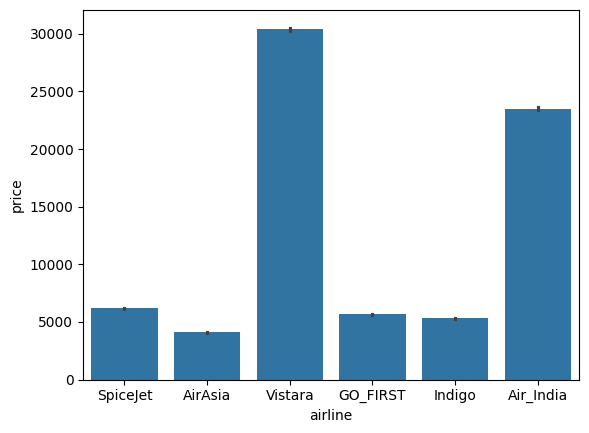

In [ ]:
# Price Distribution across Airlines
# data.groupby('airline')['price'].mean()
# data.groupby('airline')['price'].mean().round()
data.groupby('airline')['price'].mean().sort_values().round()
# sns.boxenplot(data=data,x='airline',y='price')
sns.barplot(data=data,x='airline',y='price')


<Axes: xlabel='class', ylabel='price'>

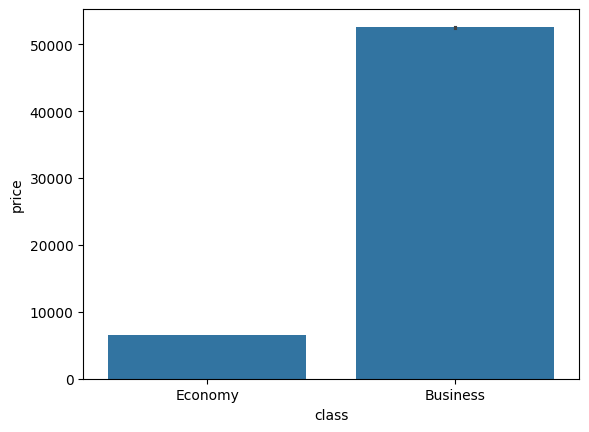

In [ ]:
# Average Price: Economy vs. Business Class
sns.barplot(data=data, x="class", y="price")

In [ ]:
# Busiest Source & Destination Cities
data.groupby(['source_city','destination_city']).size().sort_values(ascending=False)

source_city  destination_city
Delhi        Mumbai              15289
Mumbai       Delhi               14809
Delhi        Bangalore           14012
Bangalore    Delhi               13756
             Mumbai              12939
Mumbai       Bangalore           12885
             Kolkata             12602
Delhi        Kolkata             11934
Kolkata      Mumbai              11467
Delhi        Chennai             10780
Kolkata      Delhi               10506
Mumbai       Hyderabad           10470
             Chennai             10130
Hyderabad    Mumbai              10064
Bangalore    Kolkata             10028
Kolkata      Bangalore            9824
Chennai      Delhi                9783
             Mumbai               9338
Delhi        Hyderabad            9328
Bangalore    Hyderabad            8928
Hyderabad    Delhi                8506
             Kolkata              7987
Kolkata      Hyderabad            7897
Hyderabad    Bangalore            7854
Chennai      Kolkata              6983
Kolkata      Chennai              6653
Chennai      Bangalore            6493
Bangalore    Chennai              6410
Hyderabad    Chennai              6395
Chennai      Hyderabad            6103
dtype: int64

<Axes: ylabel='days_left'>

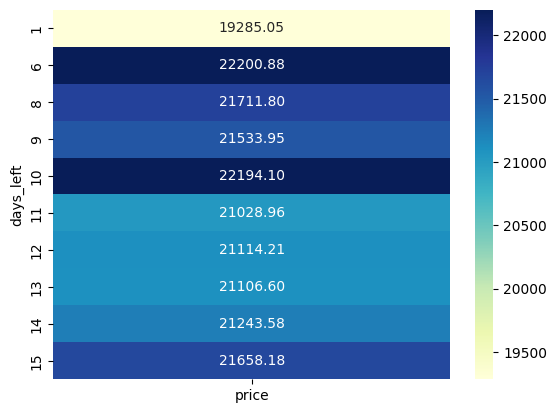

In [ ]:
# Days Left vs. Ticket Price Trend
result= data.groupby(["days_left"])["price"].std().groupby("days_left").mean().sort_values().head(10)

heatmap_data= result.reset_index().pivot_table(index= "days_left", values= "price")

sns.heatmap(data= heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f")

In [ ]:
#  Stops vs. Price Comparison
data.groupby("stops")["price"].mean().round()

,price
stops,
one,22901.0
two_or_more,14113.0
zero,9376.0


In [ ]:
#  Duration Impact on Ticket Pricing
data[["duration", "price"]].corr()

,duration,price
duration,1.000000,0.204222
price,0.204222,1.000000


In [ ]:
# 1. Find the average ticket price per airline.
query = """
SELECT airline, AVG(price) as avg_price
FROM data
"""
# # WHERE source_city = 'Delhi'
# GROUP BY airline
# ORDER BY avg_price DESC
# LIMIT 5;
# """

result = ps.sqldf(query)
print(result)

    airline     avg_price
0  SpiceJet  20889.660523


In [ ]:
#  2. List the top 5 most expensive routes (source to destination)
query = """
SELECT source_city, destination_city, ROUND(AVG(price),2) AS price
FROM data
GROUP BY source_city, destination_city
ORDER BY price DESC
LIMIT 5
"""
# GROUPBY source_city,destination_city
# ORDERBY price DESC
result = ps.sqldf(query)
print(result)

  source_city destination_city     price
0     Chennai        Bangalore  25081.85
1     Kolkata          Chennai  23660.36
2   Bangalore          Kolkata  23500.06
3   Bangalore          Chennai  23321.85
4      Mumbai        Bangalore  23147.87


In [ ]:
# 3. Which airline offers the lowest average ticket price for Business class?
query = """
SELECT airline, ROUND(MIN(price),2) AS price
FROM data
WHERE class = "Business"
GROUP BY airline
ORDER BY price
"""
result = ps.sqldf(query)
print(result)

     airline    price
0  Air_India  12000.0
1    Vistara  17604.0


In [ ]:
# 4. Find routes with more than 50 flights and their average ticket prices.
query = """
SELECT source_city,destination_city.COUNT(*) AS total_flights ROUND(avg(price),2) AS price
FROM data
WHERE class = "Business"
GROUP BY airline
ORDER BY price
"""
result = ps.sqldf(query)
print(result)

PandaSQLException: (sqlite3.OperationalError) near "(": syntax error
[SQL: 
SELECT source_city,destination_city.COUNT(*) AS total_flights ROUND(avg(price),2) AS price
FROM data
WHERE class = "Business"
GROUP BY airline
ORDER BY price
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
# 5. Compare average price difference between Economy and Business class per airline
query = """
SELECT airline,
    AVG(CASE WHEN class = "Economy" THEN price END) AS avg_economy,
                AVG(CASE WHEN class = "Business" THEN price END) AS avg_busniess,
                (AVG(CASE WHEN class = "Economy" THEN price END) -
                AVG(CASE WHEN class = "Business" THEN price END))AS price_diff

FROM data
GROUP BY airline
"""
result = ps.sqldf(query)
print(result)

     airline  avg_economy  avg_busniess    price_diff
0    AirAsia  4091.072742           NaN           NaN
1  Air_India  7313.682169  47131.039212 -39817.357044
2   GO_FIRST  5652.007595           NaN           NaN
3     Indigo  5324.216303           NaN           NaN
4   SpiceJet  6179.278881           NaN           NaN
5    Vistara  7806.943645  55477.027777 -47670.084132


In [ ]:
# 7. Which cities have the most outgoing flights?
query = """
SELECT source_city, COUNT(*) AS flight
FROM data
GROUP BY source_city
ORDER BY flight DESC
"""
result = ps.sqldf(query)
print(result)

  source_city  flight
0       Delhi   61343
1      Mumbai   60896
2   Bangalore   52061
3     Kolkata   46347
4   Hyderabad   40806
5     Chennai   38700


In [ ]:
#  8. Find the busiest route (most number of flights).
query = """
SELECT destination_city, COUNT(*) AS flight
FROM data
GROUP BY destination_city
ORDER BY flight DESC
"""
result = ps.sqldf(query)
print(result)

  destination_city  flight
0           Mumbai   59097
1            Delhi   57360
2        Bangalore   51068
3          Kolkata   49534
4        Hyderabad   42726
5          Chennai   40368
